# **Data Preprocessing**

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt


In [2]:
col_names = ["duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty_level"]

In [3]:
data = pd.read_csv('datasets/Unprocessed_data.txt', header=None, names=col_names)

In [4]:
data.drop(columns=['difficulty_level'], inplace=True)

print(data.shape)

(125973, 42)


In [5]:
data.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,182.148945,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,99.206213,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,82.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
data['label'].value_counts()

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

In [7]:
def change_label(df):
    # Use assignment to avoid chained assignment warning
    df['label'] = df['label'].replace(
        ['apache2', 'back', 'land', 'neptune', 'mailbomb', 'pod', 'processtable', 
         'smurf', 'teardrop', 'udpstorm', 'worm'], 'Dos')
    
    df['label'] = df['label'].replace(
        ['ftp_write', 'guess_passwd', 'httptunnel', 'imap', 'multihop', 'named', 
         'phf', 'sendmail', 'snmpgetattack', 'snmpguess', 'spy', 'warezclient', 
         'warezmaster', 'xlock', 'xsnoop'], 'R2L')
    
    df['label'] = df['label'].replace(
        ['ipsweep', 'mscan', 'nmap', 'portsweep', 'saint', 'satan'], 'Probe')
    
    df['label'] = df['label'].replace(
        ['buffer_overflow', 'loadmodule', 'perl', 'ps', 'rootkit', 'sqlattack', 'xterm'], 'U2R')




In [8]:
# Apply the label change function to the dataset
change_label(data)

# Check the updated label distribution
print(data['label'].value_counts())

label
normal    67343
Dos       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [9]:
data.label.value_counts()

label
normal    67343
Dos       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

# **Data Normalization**

In [10]:
import pandas as pd
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

In [11]:

# Select numeric columns from the DataFrame
numeric_col = data.select_dtypes(include='number').columns

In [12]:
# Initialize StandardScaler
std_scaler = StandardScaler()

# Function to normalize numeric columns in the DataFrame
def normalization(df, cols):
    df[cols] = std_scaler.fit_transform(df[cols])  # Fit and transform the numeric columns
    return df

# Apply normalization to the DataFrame
normalized_data = normalization(data.copy(), numeric_col)

# Display the first few rows of the normalized DataFrame
print(normalized_data.head())

   duration protocol_type   service flag  src_bytes  dst_bytes      land  \
0 -0.110249           tcp  ftp_data   SF  -0.007679  -0.004919 -0.014089   
1 -0.110249           udp     other   SF  -0.007737  -0.004919 -0.014089   
2 -0.110249           tcp   private   S0  -0.007762  -0.004919 -0.014089   
3 -0.110249           tcp      http   SF  -0.007723  -0.002891 -0.014089   
4 -0.110249           tcp      http   SF  -0.007728  -0.004814 -0.014089   

   wrong_fragment    urgent       hot  ...  dst_host_srv_count  \
0       -0.089486 -0.007736 -0.095076  ...           -0.818890   
1       -0.089486 -0.007736 -0.095076  ...           -1.035688   
2       -0.089486 -0.007736 -0.095076  ...           -0.809857   
3       -0.089486 -0.007736 -0.095076  ...            1.258754   
4       -0.089486 -0.007736 -0.095076  ...            1.258754   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0               -0.782367               -0.280282   
1               -1.161030               

In [13]:
# Apply normalization to the DataFrame and store the result back in the original variable
data = normalization(data.copy(), numeric_col)


In [14]:
data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,-0.110249,tcp,ftp_data,SF,-0.007679,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,...,-0.818890,-0.782367,-0.280282,0.069972,-0.289103,-0.639532,-0.624871,-0.224532,-0.376387,normal
1,-0.110249,udp,other,SF,-0.007737,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,...,-1.035688,-1.161030,2.736852,2.367737,-0.289103,-0.639532,-0.624871,-0.387635,-0.376387,normal
2,-0.110249,tcp,private,S0,-0.007762,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,...,-0.809857,-0.938287,-0.174417,-0.480197,-0.289103,1.608759,1.618955,-0.387635,-0.376387,Dos
3,-0.110249,tcp,http,SF,-0.007723,-0.002891,-0.014089,-0.089486,-0.007736,-0.095076,...,1.258754,1.066401,-0.439078,-0.383108,0.066252,-0.572083,-0.602433,-0.387635,-0.345084,normal
4,-0.110249,tcp,http,SF,-0.007728,-0.004814,-0.014089,-0.089486,-0.007736,-0.095076,...,1.258754,1.066401,-0.439078,-0.480197,-0.289103,-0.639532,-0.624871,-0.387635,-0.376387,normal


# **One-hot-encoding**

In [15]:
cat_col = ['protocol_type','service','flag']

In [16]:
# Select the categorical columns from the DataFrame
categorical = data[cat_col]

print(categorical.head())


  protocol_type   service flag
0           tcp  ftp_data   SF
1           udp     other   SF
2           tcp   private   S0
3           tcp      http   SF
4           tcp      http   SF


In [17]:
# Convert categorical variables to dummy/indicator variables
categorical = pd.get_dummies(categorical, columns=cat_col)

print(categorical.head())

   protocol_type_icmp  protocol_type_tcp  protocol_type_udp  service_IRC  \
0               False               True              False        False   
1               False              False               True        False   
2               False               True              False        False   
3               False               True              False        False   
4               False               True              False        False   

   service_X11  service_Z39_50  service_aol  service_auth  service_bgp  \
0        False           False        False         False        False   
1        False           False        False         False        False   
2        False           False        False         False        False   
3        False           False        False         False        False   
4        False           False        False         False        False   

   service_courier  ...  flag_REJ  flag_RSTO  flag_RSTOS0  flag_RSTR  flag_S0  \
0            Fals

# **Binary Classification**

In [18]:
# Create a binary label DataFrame
bin_label = pd.DataFrame(data['label'].map(lambda x: 'normal' if x == 'normal' else 'abnormal'))


In [19]:
# Create a copy of the original DataFrame and update the label
bin_data = data.copy()
bin_data['label'] = bin_label

In [20]:
# Initialize LabelEncoder
le1 = preprocessing.LabelEncoder()

In [21]:
# Fit the encoder on the binary labels
le1.fit(bin_label['label'])

LabelEncoder()

In [22]:
# Transform the binary labels
enc_label = le1.transform(bin_label['label'])
bin_data['intrusion'] = enc_label

# Get the classes of the LabelEncoder
print(le1.classes_)

# Save the classes to a numpy file
np.save("le1_classes.npy", le1.classes_, allow_pickle=True)

['abnormal' 'normal']


In [23]:
bin_data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,intrusion
0,-0.110249,tcp,ftp_data,SF,-0.007679,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,...,-0.782367,-0.280282,0.069972,-0.289103,-0.639532,-0.624871,-0.224532,-0.376387,normal,1
1,-0.110249,udp,other,SF,-0.007737,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,...,-1.161030,2.736852,2.367737,-0.289103,-0.639532,-0.624871,-0.387635,-0.376387,normal,1
2,-0.110249,tcp,private,S0,-0.007762,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,...,-0.938287,-0.174417,-0.480197,-0.289103,1.608759,1.618955,-0.387635,-0.376387,abnormal,0
3,-0.110249,tcp,http,SF,-0.007723,-0.002891,-0.014089,-0.089486,-0.007736,-0.095076,...,1.066401,-0.439078,-0.383108,0.066252,-0.572083,-0.602433,-0.387635,-0.345084,normal,1
4,-0.110249,tcp,http,SF,-0.007728,-0.004814,-0.014089,-0.089486,-0.007736,-0.095076,...,1.066401,-0.439078,-0.480197,-0.289103,-0.639532,-0.624871,-0.387635,-0.376387,normal,1


In [24]:
bin_data = pd.get_dummies(bin_data,columns=['label'],prefix="",prefix_sep="") 
bin_data['label'] = bin_label
bin_data



,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,intrusion,abnormal,normal,label
0,-0.110249,tcp,ftp_data,SF,-0.007679,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,...,0.069972,-0.289103,-0.639532,-0.624871,-0.224532,-0.376387,1,False,True,normal
1,-0.110249,udp,other,SF,-0.007737,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,...,2.367737,-0.289103,-0.639532,-0.624871,-0.387635,-0.376387,1,False,True,normal
2,-0.110249,tcp,private,S0,-0.007762,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,...,-0.480197,-0.289103,1.608759,1.618955,-0.387635,-0.376387,0,True,False,abnormal
3,-0.110249,tcp,http,SF,-0.007723,-0.002891,-0.014089,-0.089486,-0.007736,-0.095076,...,-0.383108,0.066252,-0.572083,-0.602433,-0.387635,-0.345084,1,False,True,normal
4,-0.110249,tcp,http,SF,-0.007728,-0.004814,-0.014089,-0.089486,-0.007736,-0.095076,...,-0.480197,-0.289103,-0.639532,-0.624871,-0.387635,-0.376387,1,False,True,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,-0.110249,tcp,private,S0,-0.007762,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,...,-0.480197,-0.289103,1.608759,1.618955,-0.387635,-0.376387,0,True,False,abnormal
125969,-0.107178,udp,private,SF,-0.007744,-0.004883,-0.014089,-0.089486,-0.007736,-0.095076,...,-0.447834,-0.289103,-0.639532,-0.624871,-0.387635,-0.376387,1,False,True,normal
125970,-0.110249,tcp,smtp,SF,-0.007382,-0.004823,-0.014089,-0.089486,-0.007736,-0.095076,...,-0.480197,-0.289103,0.979238,-0.624871,-0.355014,-0.376387,1,False,True,normal
125971,-0.110249,tcp,klogin,S0,-0.007762,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,...,-0.480197,-0.289103,1.608759,1.618955,-0.387635,-0.376387,0,True,False,abnormal


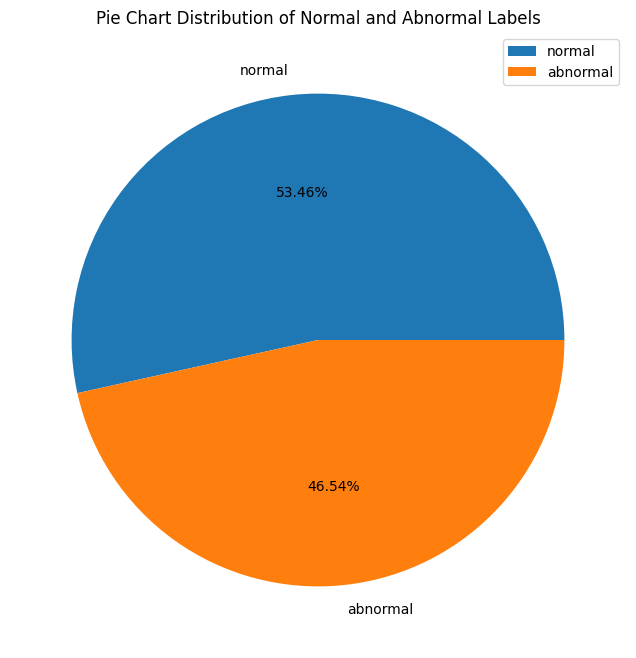

In [25]:


# Create the directory if it doesn't exist
output_dir = 'plots'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Create a pie chart to show the distribution of normal and abnormal labels
plt.figure(figsize=(8, 8))
plt.pie(bin_data['label'].value_counts(), labels=bin_data['label'].unique(), autopct='%0.2f%%')
plt.title("Pie Chart Distribution of Normal and Abnormal Labels")
plt.legend()

# Save the pie chart as an image file in the 'plots' folder
plt.savefig(os.path.join(output_dir, 'Pie_chart_binary.png'))
plt.show()  # Display the pie chart


# **Multi-class Classification**

In [26]:
# Create a copy of the original DataFrame
multi_data = data.copy()

# Initialize a new DataFrame for the labels
multi_label = pd.DataFrame(multi_data['label'])

# Display the first few rows of multi_label to verify
print(multi_label.head())


    label
0  normal
1  normal
2     Dos
3  normal
4  normal


In [27]:

from sklearn import preprocessing

# Initialize a new LabelEncoder
le2 = preprocessing.LabelEncoder()

# Fit and transform the labels in multi_label and assign to multi_data
multi_data['intrusion'] = le2.fit_transform(multi_label['label'])

# Display the unique classes encoded
print(le2.classes_)


['Dos' 'Probe' 'R2L' 'U2R' 'normal']


In [28]:
# Display the unique classes encoded by the second LabelEncoder
print("Encoded classes:", le2.classes_)

Encoded classes: ['Dos' 'Probe' 'R2L' 'U2R' 'normal']


In [29]:
np.save("le2_classes.npy", le2.classes_, allow_pickle=True)

In [30]:
# Convert the 'label' column in multi_data to dummy/indicator variables
multi_data = pd.get_dummies(multi_data, columns=['label'], prefix="", prefix_sep="")

# Update the 'label' column in multi_data with the original multi_label
multi_data['label'] = multi_label['label']

In [31]:
print(multi_data.head())

   duration protocol_type   service flag  src_bytes  dst_bytes      land  \
0 -0.110249           tcp  ftp_data   SF  -0.007679  -0.004919 -0.014089   
1 -0.110249           udp     other   SF  -0.007737  -0.004919 -0.014089   
2 -0.110249           tcp   private   S0  -0.007762  -0.004919 -0.014089   
3 -0.110249           tcp      http   SF  -0.007723  -0.002891 -0.014089   
4 -0.110249           tcp      http   SF  -0.007728  -0.004814 -0.014089   

   wrong_fragment    urgent       hot  ...  dst_host_srv_serror_rate  \
0       -0.089486 -0.007736 -0.095076  ...                 -0.624871   
1       -0.089486 -0.007736 -0.095076  ...                 -0.624871   
2       -0.089486 -0.007736 -0.095076  ...                  1.618955   
3       -0.089486 -0.007736 -0.095076  ...                 -0.602433   
4       -0.089486 -0.007736 -0.095076  ...                 -0.624871   

   dst_host_rerror_rate  dst_host_srv_rerror_rate  intrusion    Dos  Probe  \
0             -0.224532         

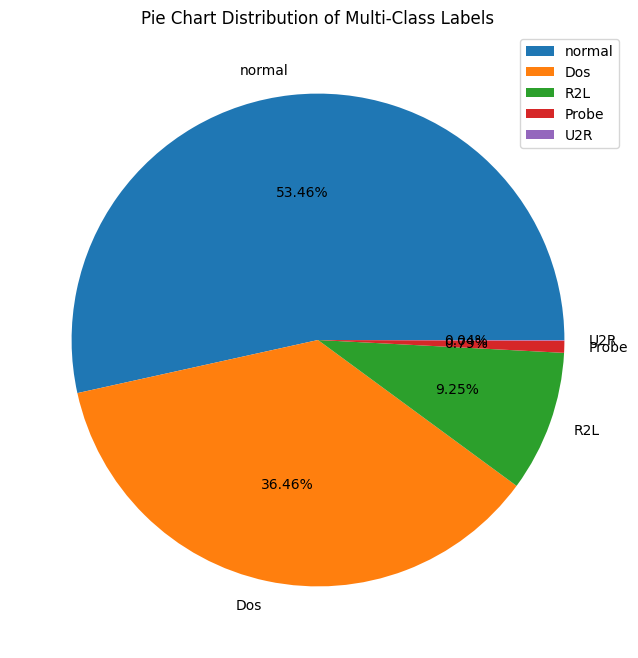

In [32]:

# Create a pie chart to show the distribution of multi-class labels
plt.figure(figsize=(8, 8))
plt.pie(multi_data['label'].value_counts(), labels=multi_data['label'].unique(), autopct='%0.2f%%')
plt.title('Pie Chart Distribution of Multi-Class Labels')
plt.legend()
plt.savefig('plots/Pie_chart_multi.png')  # Save the pie chart as an image file
plt.show()  # Display the pie chart

# **Feature Extraction**

In [33]:
# Select numeric columns and create a new DataFrame
numeric_bin = bin_data[numeric_col].copy()  # Use .copy() to avoid SettingWithCopyWarning

# Add the 'intrusion' column to the numeric_bin DataFrame
numeric_bin['intrusion'] = bin_data['intrusion'].values  # Use .values for assignment    

In [34]:
# Calculate the correlation matrix
corr = numeric_bin.corr()

# Get the absolute correlation values with respect to the 'intrusion' column
corr_y = abs(corr['intrusion'])

# Select features with a correlation greater than 0.5
highest_corr = corr_y[corr_y > 0.5]

# Sort the correlated features in ascending order
sorted_highest_corr = highest_corr.sort_values(ascending=True)

# Display the results
print(sorted_highest_corr)

count                       0.576444
srv_serror_rate             0.648289
serror_rate                 0.650652
dst_host_serror_rate        0.651842
dst_host_srv_serror_rate    0.654985
logged_in                   0.690171
dst_host_same_srv_rate      0.693803
dst_host_srv_count          0.722535
same_srv_rate               0.751913
intrusion                   1.000000
Name: intrusion, dtype: float64


In [35]:
# Select specific numeric columns for the binary dataset
numeric_bin = bin_data[['count', 'srv_serror_rate', 'serror_rate', 'dst_host_serror_rate', 
                         'dst_host_srv_serror_rate', 'logged_in', 'dst_host_same_srv_rate', 
                         'dst_host_srv_count', 'same_srv_rate']].copy()  # Use .copy() to avoid SettingWithCopyWarning

In [36]:
# Join the categorical DataFrame to the numeric_bin DataFrame
numeric_bin = numeric_bin.join(categorical)

# Join the intrusion and label columns to create the final bin_data DataFrame
bin_data = numeric_bin.join(bin_data[['intrusion', 'abnormal', 'normal', 'label']])

In [37]:
# Save the final DataFrame to a CSV file
bin_data.to_csv("./datasets/bin_data.csv", index=False)  # Set index=False to avoid writing row indices

# Display the final bin_data DataFrame
print(bin_data.head())  # Optionally print the first few rows for verification


      count  srv_serror_rate  serror_rate  dst_host_serror_rate  \
0 -0.717045        -0.631929    -0.637209             -0.639532   
1 -0.620982        -0.631929    -0.637209             -0.639532   
2  0.339648         1.605104     1.602664              1.608759   
3 -0.690846        -0.184522    -0.189235             -0.572083   
4 -0.472521        -0.631929    -0.637209             -0.639532   

   dst_host_srv_serror_rate  logged_in  dst_host_same_srv_rate  \
0                 -0.624871  -0.809262               -0.782367   
1                 -0.624871  -0.809262               -1.161030   
2                  1.618955  -0.809262               -0.938287   
3                 -0.602433   1.235694                1.066401   
4                 -0.624871   1.235694                1.066401   

   dst_host_srv_count  same_srv_rate  protocol_type_icmp  ...  flag_S0  \
0           -0.818890       0.771283               False  ...    False   
1           -1.035688      -1.321428               F

In [38]:
# Select numeric columns for the multi-class dataset
numeric_multi = multi_data[numeric_col].copy()  # Use .copy() to avoid SettingWithCopyWarning

# Add the 'intrusion' column to the numeric_multi DataFrame
numeric_multi['intrusion'] = multi_data['intrusion'].values  # Use .values for assignment

In [39]:
# Calculate the correlation matrix
corr = numeric_multi.corr()

# Get the absolute correlation values with respect to the 'intrusion' column
corr_y = abs(corr['intrusion'])

# Select features with a correlation greater than 0.5
highest_corr = corr_y[corr_y > 0.5]

In [40]:

# Sort the correlated features in ascending order
sorted_highest_corr = highest_corr.sort_values(ascending=True)

# Print the sorted highest correlations (optional)
print(sorted_highest_corr)

count                       0.613251
logged_in                   0.693770
srv_serror_rate             0.710852
serror_rate                 0.712861
dst_host_serror_rate        0.714247
dst_host_same_srv_rate      0.716820
dst_host_srv_serror_rate    0.717387
dst_host_srv_count          0.718579
same_srv_rate               0.798358
intrusion                   1.000000
Name: intrusion, dtype: float64


In [41]:

# Select specific numeric columns for the multi-class dataset
numeric_multi = multi_data[['count', 'logged_in', 'srv_serror_rate', 'serror_rate', 
                             'dst_host_serror_rate', 'dst_host_same_srv_rate', 
                             'dst_host_srv_serror_rate', 'dst_host_srv_count', 
                             'same_srv_rate']].copy()  # Use .copy() to avoid SettingWithCopyWarning

# Join the categorical DataFrame to the numeric_multi DataFrame
numeric_multi = numeric_multi.join(categorical)

In [42]:
# Join the intrusion and label columns to create the final multi_data DataFrame
multi_data = numeric_multi.join(multi_data[['intrusion', 'Dos', 'Probe', 'R2L', 'U2R', 'normal', 'label']])

# Save the final DataFrame to a CSV file
multi_data.to_csv('./datasets/multi_data.csv', index=False)  # Set index=False to avoid writing row indices

In [43]:

# Display the final multi_data DataFrame
print(multi_data.head())  # Optionally print the first few rows for verification

      count  logged_in  srv_serror_rate  serror_rate  dst_host_serror_rate  \
0 -0.717045  -0.809262        -0.631929    -0.637209             -0.639532   
1 -0.620982  -0.809262        -0.631929    -0.637209             -0.639532   
2  0.339648  -0.809262         1.605104     1.602664              1.608759   
3 -0.690846   1.235694        -0.184522    -0.189235             -0.572083   
4 -0.472521   1.235694        -0.631929    -0.637209             -0.639532   

   dst_host_same_srv_rate  dst_host_srv_serror_rate  dst_host_srv_count  \
0               -0.782367                 -0.624871           -0.818890   
1               -1.161030                 -0.624871           -1.035688   
2               -0.938287                  1.618955           -0.809857   
3                1.066401                 -0.602433            1.258754   
4                1.066401                 -0.624871            1.258754   

   same_srv_rate  protocol_type_icmp  ...  flag_S3  flag_SF  flag_SH  \
0       